In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

new_rc_params = {"text.usetex": False, "svg.fonttype": "none"}
mpl.rcParams.update(new_rc_params)
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["font.size"] = 12

%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
from chiCa.chiCa.chipmunk_analysis_tools import load_trialdata

chicadata = load_trialdata(
    "/Users/gabriel/data/GRB006/20240821_121447/chipmunk/GRB006_20240821_121447_chipmunk_DemonstratorAudiTask.mat"
)

In [3]:
chicadata["bpod_ts"] = chicadata.apply(
    lambda row: row.trial_start_time + row.stimulus_event_timestamps, axis=1
)
chicadata["first_bpod_ts"] = chicadata.apply(
    lambda row: row.trial_start_time + row.stimulus_event_timestamps[0], axis=1
)
chicadata = chicadata[chicadata.response_side.isin([0, 1])]

In [4]:
chicadata.PreStimPeriod.apply(lambda x: np.diff(x)[0])

2      0.0729
3      0.0390
4      0.0104
6      0.0654
10     0.0106
        ...  
491    0.0271
496    0.0523
499    0.0819
500    0.0475
502    0.0203
Name: PreStimPeriod, Length: 294, dtype: float64

In [5]:
# bpod_data = pd.DataFrame((Chipmunk.Trial() & 'subject_name = "GRB006"' & 'session_datetime LIKE "2024-08-21%"').fetch("trial_start", "stimulus_event_timestamps", "with_choice", as_dict=True))
# bpod_data['bpod_ts'] = bpod_data.apply(lambda row: row.trial_start + row.stimulus_event_timestamps, axis = 1)
# bpod_data = bpod_data[bpod_data.with_choice == 1]
# bpod_ts = np.hstack(bpod_data.bpod_ts)

In [6]:
# d = pd.DataFrame((Chipmunk.Trial() & 'subject_name = "GRB006"' & 'session_datetime LIKE "2024-08-21%"').fetch("trial_start", "stimulus_event_timestamps", "with_choice", as_dict=True))
# sess_start = d.iloc[0].trial_start
# d['corrected_start'] = d.apply(lambda row: row.trial_start - sess_start, axis = 1)
# d['corrected_bpod_ts'] = d.apply(lambda row: row.corrected_start + row.stimulus_event_timestamps, axis = 1)
# d = d[d.with_choice == 1]
# d_ts = np.hstack(d.corrected_bpod_ts)

In [7]:
trial_ts = pd.read_pickle(
    "/Users/gabriel/data/GRB006/20240821_121447/pre_processed/trial_ts.pkl"
)
trial_ts = trial_ts[trial_ts.response_side.isin([0, 1])]
nidaq_ts = np.hstack(trial_ts.stim_ts)
first_nidaq_ts = np.hstack(trial_ts.first_stim_ts)

In [53]:
trial_ts

,category,trial_rate,detected_events,trial_start,stim_ts,first_stim_ts,stimulus_modality,response_side,correct_side,trial_outcome,...,center_port_exits,left_port_entries,left_port_exits,right_port_entries,right_port_exits,stim_ts_visual,stim_ts_audio,response,stationary_stims,movement_stims
2,boundary,12,12,74.036567,"[89.55855733333334, 89.63860533333335, 89.6786...",89.558557,visual,1.0,1,1,...,[90.0619],[],[],[91.0864],[],"[89.55855733333334, 89.63860533333335, 89.6786...",[],91.086400,"[89.55855733333334, 89.63860533333335, 89.6786...","[90.11855733333334, 90.15860533333334, 90.2384..."
3,left,6,6,91.156133,"[95.46997999999999, 95.51002799999999, 95.9099...",95.469980,visual,0.0,0,1,...,[96.07383333333334],[96.92466666666667],[],[],[94.70476666666667],"[95.46997999999999, 95.51002799999999, 95.9099...",[],96.924667,"[95.46997999999999, 95.51002799999999, 95.9099...","[96.1899604512, 96.3499391184]"
4,boundary,12,11,96.998700,"[100.70418533333334, 100.86416933333334, 100.9...",100.704185,visual,0.0,1,0,...,[101.21323333333333],[101.63596666666666],"[98.72263333333333, 102.2096]",[],[],"[100.70418533333334, 100.86416933333334, 100.9...",[],101.635967,"[100.70418533333334, 100.86416933333334, 100.9...","[101.26402822285156, 101.30402886286181, 101.3..."
6,right,14,14,106.161333,"[106.82348, 106.94346399999999, 107.023464, 10...",106.823480,visual,0.0,1,0,...,[107.53126666666667],"[108.09196666666666, 108.48053333333333]","[108.48053333333333, 108.4806]",[],[],"[106.82348, 106.94346399999999, 107.023464, 10...",[],108.091967,"[106.82348, 106.94346399999999, 107.023464, 10...","[107.62338199999999, 107.66338066666667, 107.7..."
10,right,20,20,122.449267,"[123.6510824189187, 123.69108305892895, 123.73...",123.651082,visual,1.0,1,1,...,[124.16796666666667],[],[],[125.0762],[],"[123.6510824189187, 123.69108305892895, 123.73...",[],125.076200,"[123.6510824189187, 123.69108305892895, 123.73...","[124.17104133333333, 124.21104133333334, 124.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,boundary,12,12,3072.152833,"[3073.616822666667, 3073.736918666667, 3073.77...",3073.616823,visual,0.0,0,1,...,[3074.1439],[3074.7429],[],[],[],"[3073.616822666667, 3073.736918666667, 3073.77...",[],3074.742900,"[3073.616822666667, 3073.736918666667, 3073.77...","[3074.3367492602665, 3074.4168425904, 3074.456..."
496,right,16,16,3127.793567,"[3132.890848, 3132.930736, 3133.010784, 3133.1...",3132.890848,visual,1.0,1,1,...,[3133.4021666666667],[],[],[3133.8672333333334],[],"[3132.890848, 3132.930736, 3133.010784, 3133.1...",[],3133.867233,"[3132.890848, 3132.930736, 3133.010784, 3133.1...","[3133.4506747770665, 3133.5307201088003, 3133...."
499,left,8,8,3144.649067,"[3145.7081331349304, 3145.7480697739165, 3145....",3145.708133,visual,1.0,0,0,...,[3146.2286],[],[],[3146.8413],[3147.519333333333],"[3145.7081331349304, 3145.7480697739165, 3145....",[],3146.841300,"[3145.7081331349304, 3145.7480697739165, 3145....","[3146.3080181946666, 3146.4679968618666, 3146...."
500,left,10,10,3147.894400,"[3151.8542, 3151.934088, 3151.974088, 3152.054...",3151.854200,visual,1.0,0,0,...,[3152.381733333333],[],[],[3152.85],[3153.3091],"[3151.8542, 3151.934088, 3151.974088, 3152.054...",[],3152.850000,"[3151.8542, 3151.934088, 3151.974088, 3152.054...","[3152.4140457639323, 3152.4540464039424, 3152...."


Text(0.5, 1.0, 'negative means nidaq is lagging behind bpod')

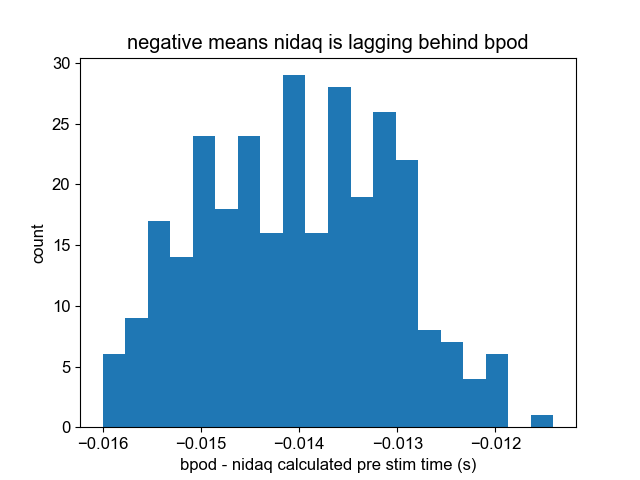

In [9]:
plt.figure()
plt.hist(
    (chicadata.PreStimPeriod.apply(lambda x: np.diff(x)[0]))
    - (trial_ts.first_stim_ts - trial_ts.center_port_entries.apply(lambda x: x[0])),
    bins=20,
)
plt.xlabel("bpod - nidaq calculated pre stim time (s)")
plt.ylabel("count")
plt.title("negative means nidaq is lagging behind bpod")

In [117]:
chicadata.PreStimPeriod.apply(lambda x: np.diff(x)[0])

2      0.0729
3      0.0390
4      0.0104
6      0.0654
10     0.0106
        ...  
491    0.0271
496    0.0523
499    0.0819
500    0.0475
502    0.0203
Name: PreStimPeriod, Length: 294, dtype: float64

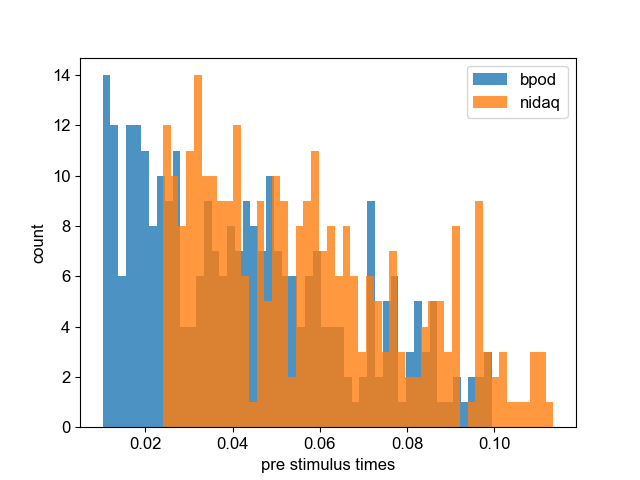

In [ ]:
plt.figure()
plt.hist(
    chicadata.PreStimPeriod.apply(lambda x: np.diff(x)[0]),
    bins=50,
    label="bpod",
    alpha=0.8,
)
plt.hist(
    trial_ts.first_stim_ts - trial_ts.center_port_entries.apply(lambda x: x[0]),
    bins=50,
    label="nidaq",
    alpha=0.8,
)
plt.xlabel("pre stimulus times")
plt.ylabel("count")
plt.legend();

In [11]:
center_onset = chicadata.DemonWaitForCenterFixation.apply(lambda x: x[-1])
center_stim = chicadata.stimulus_event_timestamps.apply(lambda x: x[0])
center_stim - center_onset

2      0.0730
3      0.0391
4      0.0105
6      0.0655
10     0.0107
        ...  
491    0.0272
496    0.0524
499    0.0820
500    0.0476
502    0.0204
Length: 294, dtype: float64

In [13]:
# corrected_bpod_ts = np.hstack(bpod_data.bpod_ts - (bpod_data.trial_start - trial_ts.trial_start))
corrected_chica_ts = np.hstack(
    chicadata.bpod_ts - (chicadata.trial_start_time - trial_ts.trial_start)
)
corrected_chica_first_stim = np.hstack(
    chicadata.first_bpod_ts - (chicadata.trial_start_time - trial_ts.trial_start)
)
np.diff(corrected_chica_ts).min()

0.03999999999996362

In [14]:
raw_data = pd.read_pickle(
    "/Users/gabriel/Downloads/GRB006_20240821_121447_session_outputs.pkl"
)
# new_nidaq = np.hstack(raw_data['trial_ts'].stim_ts)

In [131]:
from ephys.utils.utils_IO import detect_stim_events, get_trial_ts

stim_ts_per_channel = {}
stim_ts_per_channel["visual"] = detect_stim_events(
    raw_data["time_vector"],
    raw_data["sampling_rate"],
    raw_data["analog_signals"]["visual"],
    amp_threshold=5000,
    time_threshold=0.04,
)

raw_ts = get_trial_ts(
    raw_data["trial_starts"],
    stim_ts_per_channel,
    raw_data["behavior_data"],
    raw_data["port_events"],
)

raw_ts = raw_ts[raw_ts.response_side.isin([0, 1])]
raw_nidaq = np.hstack(raw_ts.stim_ts)

In [132]:
raw_ts

,trial_rate,detected_events,trial_start,stim_ts,first_stim_ts,stimulus_modality,response_side,correct_side,trial_outcome,center_port_entries,center_port_exits,left_port_entries,left_port_exits,right_port_entries,right_port_exits,stim_ts_visual
2,12,12,74.036567,"[89.55855733333334, 89.63860533333335, 89.6786...",89.558557,visual,1.0,1,1,[89.47103333333334],[90.0619],[],[],[91.0864],[],"[89.55855733333334, 89.63860533333335, 89.6786..."
3,6,6,91.156133,"[95.46997999999999, 95.51002799999999, 95.9099...",95.469980,visual,0.0,0,1,[95.4191],[96.07383333333334],[96.92466666666667],[],[],[94.70476666666667],"[95.46997999999999, 95.51002799999999, 95.9099..."
4,12,11,96.998700,"[100.70418533333334, 100.86416933333334, 100.9...",100.704185,visual,0.0,1,0,[100.6796],[101.21323333333333],[101.63596666666666],"[98.72263333333333, 102.2096]",[],[],"[100.70418533333334, 100.86416933333334, 100.9..."
6,14,14,106.161333,"[106.82348, 106.94346399999999, 107.023464, 10...",106.823480,visual,0.0,1,0,[106.74373333333334],[107.53126666666667],"[108.09196666666666, 108.48053333333333]","[108.48053333333333, 108.4806]",[],[],"[106.82348, 106.94346399999999, 107.023464, 10..."
10,20,20,122.449267,"[123.6510824189187, 123.69108305892895, 123.73...",123.651082,visual,1.0,1,1,[123.62593333333334],[124.16796666666667],[],[],[125.0762],[],"[123.6510824189187, 123.69108305892895, 123.73..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,12,12,3072.152833,"[3073.616822666667, 3073.736918666667, 3073.77...",3073.616823,visual,0.0,0,1,[3073.5753],[3074.1439],[3074.7429],[],[],[],"[3073.616822666667, 3073.736918666667, 3073.77..."
496,16,16,3127.793567,"[3132.890848, 3132.930736, 3133.010784, 3133.1...",3132.890848,visual,1.0,1,1,[3132.8246],[3133.4021666666667],[],[],[3133.8672333333334],[],"[3132.890848, 3132.930736, 3133.010784, 3133.1..."
499,8,8,3144.649067,"[3145.7081331349304, 3145.7480697739165, 3145....",3145.708133,visual,1.0,0,0,[3145.6122666666665],[3146.2286],[],[],[3146.8413],[3147.519333333333],"[3145.7081331349304, 3145.7480697739165, 3145...."
500,10,10,3147.894400,"[3151.8542, 3151.934088, 3151.974088, 3152.054...",3151.854200,visual,1.0,0,0,[3151.7935333333335],[3152.381733333333],[],[],[3152.85],[3153.3091],"[3151.8542, 3151.934088, 3151.974088, 3152.054..."


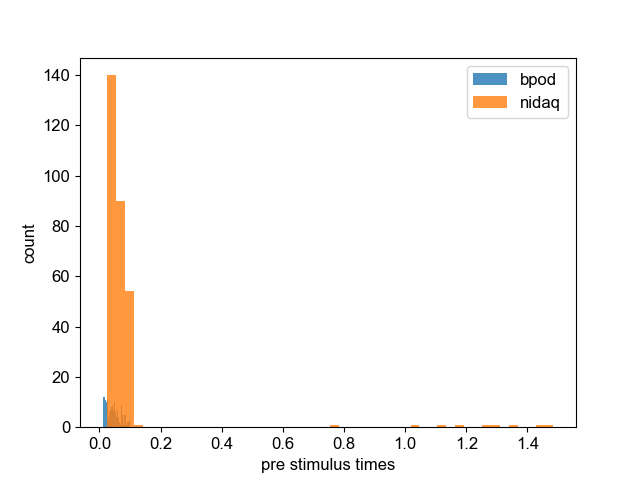

In [133]:
plt.figure()
plt.hist(
    chicadata.PreStimPeriod.apply(lambda x: np.diff(x)[0]),
    bins=50,
    label="bpod",
    alpha=0.8,
)
plt.hist(
    raw_ts.first_stim_ts - raw_ts.center_port_entries.apply(lambda x: x[0]),
    bins=50,
    label="nidaq",
    alpha=0.8,
)
plt.xlabel("pre stimulus times")
plt.ylabel("count")
plt.legend();

In [129]:
len(nidaq_ts), len(raw_nidaq)

(3502, 3502)

In [135]:
(raw_ts.first_stim_ts - raw_ts.center_port_entries.apply(lambda x: x[0])).min()

0.024196958933316637

(array([   0.,    0.,    0.,    0.,    0., 3502.,    0.,    0.,    0.,
           0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

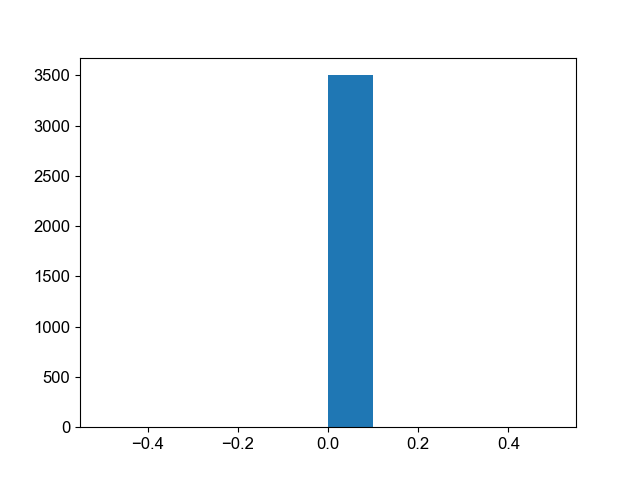

In [134]:
plt.figure()
plt.hist(raw_nidaq - nidaq_ts, bins=10)

(89.0, 99.0)

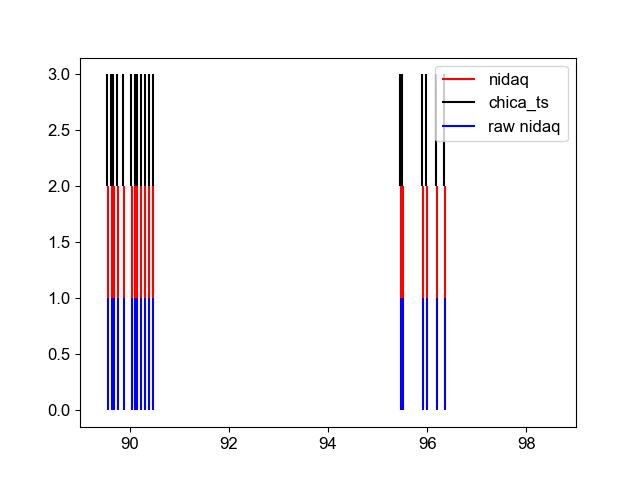

In [99]:
plt.figure()
# plt.vlines(corrected_bpod_ts + 0.015, 0, 1, label = 'bpod', color='b')
plt.vlines(nidaq_ts, 1, 2, label="nidaq", color="r")
plt.vlines(corrected_chica_ts, 2, 3, label="chica_ts", color="k")
plt.vlines(raw_nidaq, 0, 1, label="raw nidaq", color="b")
plt.legend()
plt.xlim([89, 99])

(89.0, 92.0)

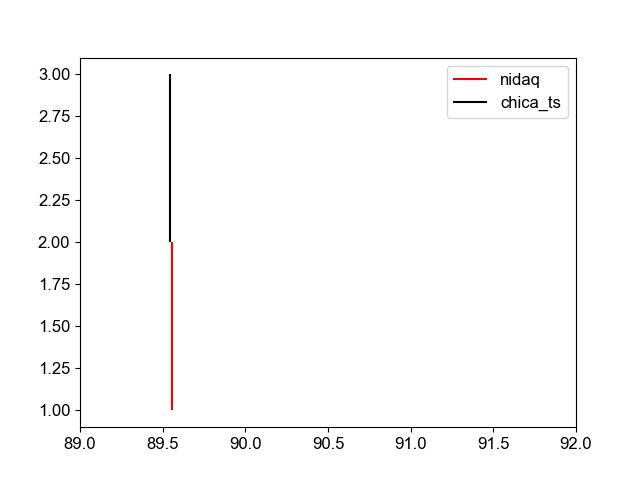

In [17]:
plt.figure()
plt.vlines(first_nidaq_ts, 1, 2, label="nidaq", color="r")
plt.vlines(corrected_chica_first_stim, 2, 3, label="chica_ts", color="k")
plt.legend()
plt.xlim([89, 92])

In [18]:
first_offsets = []
for nidaq, chica in zip(first_nidaq_ts, corrected_chica_first_stim):
    first_offsets.append(nidaq - chica)

first_offsets = np.array(first_offsets)

In [19]:
print(f" range of offsets is: {(first_offsets.max() - first_offsets.min()) * 1000:.2f}")

 range of offsets is: 4.50


Text(0, 0.5, 'count')

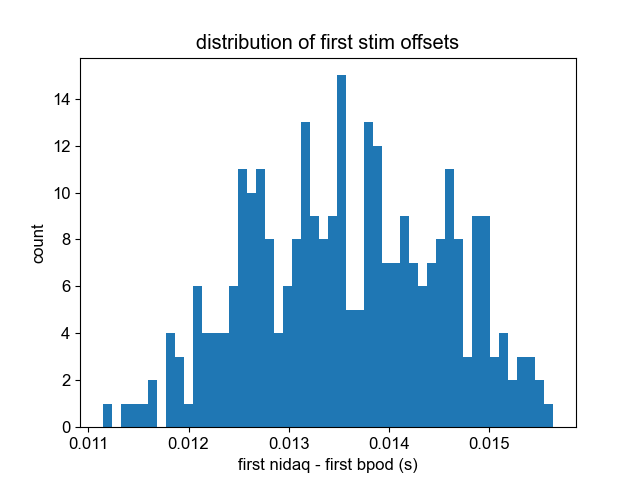

In [20]:
plt.figure()
plt.hist(first_offsets, bins=50)
plt.title("distribution of first stim offsets")
plt.xlabel("first nidaq - first bpod (s)")
plt.ylabel("count")

In [ ]:
prestims = {
    "nidaq_prestims": trial_ts.stim_ts.apply(lambda x: x[0])
    - trial_ts.center_port_entries.apply(lambda x: x[0]),
    "bpod_prestims": center_stim - center_onset,
}
d = pd.DataFrame(prestims)
d["diff"] = d["nidaq_prestims"] - d["bpod_prestims"]
d

TODO:
- ~~check delay between all the first stims between bpod and nidaq~~
- is there any event happening before the first stim in the bpod timestamps?
- is the alignment between neural and behavioral data okay? look into the load_sync_data function

In [21]:
t = raw_data["time_vector"]
raw_vis = raw_data["analog_signals"]["visual"]
raw_vis_ts = np.hstack(raw_data["trial_ts"]["stim_ts"])
first_vis_ts = np.hstack(raw_data["trial_ts"]["first_stim_ts"])

In [22]:
np.diff(raw_data["trial_ts"].stim_ts.iloc[0])[0] > 0.041

True

In [23]:
raw_data["trial_ts"].stim_ts.iloc[0]

array([63.46521277, 63.54526205, 63.62519933, 63.66519997, 63.70520061,
       63.78529789, 63.82518653, 63.86518717, 63.90523581, 63.94528445,
       64.02517373, 64.06522237, 64.10527067, 64.18515867, 64.22520667,
       64.26525467, 64.34514267, 64.38519067])

In [24]:
iso_first_ts = []
for _, stims in enumerate(raw_data["trial_ts"].stim_ts):
    if np.diff(stims)[0] > 0.041:
        iso_first_ts.append(stims[0])

iso_first_ts = np.array(iso_first_ts)

In [25]:
# # Option 1: Plot all trials in separate subplots (show all trials)
# n_trials = len(iso_first_ts)  # Show all trials
# n_cols = 10  # Changed from 20 to 10
# n_rows = int(np.ceil(n_trials / n_cols))

# fig, axes = plt.subplots(
#     n_rows, n_cols, figsize=(20, 2 * n_rows), sharex=True, sharey=True
# )
# axes = axes.flatten()

# window_ms = 50  # 50ms window
# window_sec = window_ms / 1000

# for i, stim_time in enumerate(iso_first_ts):
#     start_time = stim_time - window_sec
#     end_time = stim_time + window_sec

#     start_idx = int(np.searchsorted(t, start_time))
#     end_idx = int(np.searchsorted(t, end_time))

#     time_window = t[start_idx:end_idx] - stim_time  # Center around stim
#     signal_window = raw_vis[start_idx:end_idx]

#     axes[i].plot(time_window * 1000, signal_window, "b-", alpha=0.7)
#     axes[i].axvline(0, color="r", linestyle="--", alpha=0.8)
#     axes[i].set_title(f"Trial {i + 1}", fontsize=8)
#     axes[i].grid(True, alpha=0.3)

#     if i >= (n_rows - 1) * n_cols:  # Bottom row
#         axes[i].set_xlabel("Time (ms)", fontsize=8)
#     if i % n_cols == 0:  # Left column
#         axes[i].set_ylabel("Signal", fontsize=8)

# # Hide unused subplots
# for i in range(n_trials, len(axes)):
#     axes[i].set_visible(False)

# plt.tight_layout()
# plt.suptitle(
#     f"Visual Signal Around First Isolated Stimulus (±50ms) - All {n_trials} Trials",
#     y=1.02,
# )

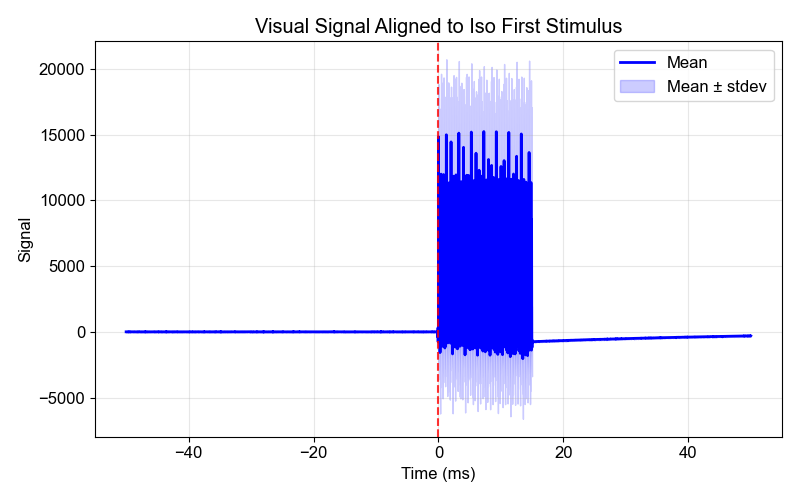

In [26]:
# ...existing code...
# Option 2: Overlay all trials on one axis with mean trace (fixed-length windows)
window_ms = 50
window_sec = window_ms / 1000

dt = np.mean(np.diff(t))  # sampling interval (s)
n_samples = int(np.round(2 * window_sec / dt)) + 1  # +/- window, symmetric

all_traces = []
time_axis = None

for stim_time in iso_first_ts:
    # find center index
    center_idx = int(np.searchsorted(t, stim_time))

    start_idx = center_idx - n_samples // 2
    end_idx = start_idx + n_samples

    # skip if window would go out of bounds
    if start_idx < 0 or end_idx > len(t):
        continue

    time_window = t[start_idx:end_idx] - stim_time
    signal_window = raw_vis[start_idx:end_idx]

    if time_axis is None:
        time_axis = time_window * 1000  # ms

    all_traces.append(signal_window)

all_traces = np.vstack(all_traces)  # (n_trials, n_samples)
mean_trace = all_traces.mean(axis=0)
sem_trace = all_traces.std(axis=0)  # / np.sqrt(all_traces.shape[0])

plt.figure(figsize=(8, 5))
# for trial_trace in all_traces:
#     plt.plot(time_axis, trial_trace, color='lightgray', alpha=0.3)

plt.plot(time_axis, mean_trace, color="b", linewidth=2, label="Mean")
plt.fill_between(
    time_axis,
    mean_trace - sem_trace,
    mean_trace + sem_trace,
    color="b",
    alpha=0.2,
    label="Mean ± stdev",
)
plt.axvline(0, color="r", linestyle="--", alpha=0.8)
plt.xlabel("Time (ms)")
plt.ylabel("Signal")
plt.title("Visual Signal Aligned to Iso First Stimulus")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# ...existing code...

In [27]:
# # Option 1: Plot all trials in separate subplots (show all trials)
# n_trials = len(first_vis_ts)  # Show all trials
# n_cols = 10  # Changed from 20 to 10
# n_rows = int(np.ceil(n_trials / n_cols))

# fig, axes = plt.subplots(
#     n_rows, n_cols, figsize=(20, 2 * n_rows), sharex=True, sharey=True
# )
# axes = axes.flatten()

# window_ms = 50  # 50ms window
# window_sec = window_ms / 1000

# for i, stim_time in enumerate(first_vis_ts):
#     start_time = stim_time - window_sec
#     end_time = stim_time + window_sec

#     start_idx = int(np.searchsorted(t, start_time))
#     end_idx = int(np.searchsorted(t, end_time))

#     time_window = t[start_idx:end_idx] - stim_time  # Center around stim
#     signal_window = raw_vis[start_idx:end_idx]

#     axes[i].plot(time_window * 1000, signal_window, "b-", alpha=0.7)
#     axes[i].axvline(0, color="r", linestyle="--", alpha=0.8)
#     axes[i].set_title(f"Trial {i + 1}", fontsize=8)
#     axes[i].grid(True, alpha=0.3)

#     if i >= (n_rows - 1) * n_cols:  # Bottom row
#         axes[i].set_xlabel("Time (ms)", fontsize=8)
#     if i % n_cols == 0:  # Left column
#         axes[i].set_ylabel("Signal", fontsize=8)

# # Hide unused subplots
# for i in range(n_trials, len(axes)):
#     axes[i].set_visible(False)

# plt.tight_layout()
# plt.suptitle(
#     f"Visual Signal Around First Stimulus (±50ms) - All {n_trials} Trials", y=1.02
# )

In [28]:
# # Option 1: Plot all trials in separate subplots (show all trials)
# n_trials = len(first_vis_ts)  # Show all trials
# n_cols = 10  # Changed from 20 to 10
# n_rows = int(np.ceil(n_trials / n_cols))

# fig, axes = plt.subplots(
#     n_rows, n_cols, figsize=(20, 2 * n_rows), sharex=True, sharey=True
# )
# axes = axes.flatten()

# window_ms = 50  # 50ms window
# window_sec = window_ms / 1000

# for i, stim_time in enumerate(first_vis_ts):
#     start_time = stim_time - window_sec
#     end_time = stim_time + window_sec

#     start_idx = int(np.searchsorted(t, start_time))
#     end_idx = int(np.searchsorted(t, end_time))

#     time_window = t[start_idx:end_idx] - stim_time  # Center around stim
#     signal_window = raw_vis[start_idx:end_idx]

#     axes[i].plot(time_window * 1000, signal_window, "b-", alpha=0.7)
#     axes[i].axvline(0, color="r", linestyle="--", alpha=0.8)
#     axes[i].set_title(f"Trial {i + 1}", fontsize=8)
#     axes[i].grid(True, alpha=0.3)

#     if i >= (n_rows - 1) * n_cols:  # Bottom row
#         axes[i].set_xlabel("Time (ms)", fontsize=8)
#     if i % n_cols == 0:  # Left column
#         axes[i].set_ylabel("Signal", fontsize=8)

# # Hide unused subplots
# for i in range(n_trials, len(axes)):
#     axes[i].set_visible(False)

# plt.tight_layout()
# plt.suptitle(
#     f"Visual Signal Around First Stimulus (±50ms) - All {n_trials} Trials", y=1.02
# )

In [93]:
ii = np.where(np.diff(raw_vis > 15000) == 1)[0]
x = np.hstack([0, ii])
len(t[ii[np.diff(x) > 0.0001 * 30000]])

263398

/var/folders/k4/_l1cqd4d0gn02n75d0rrj10h0000gr/T/ipykernel_59800/156288399.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


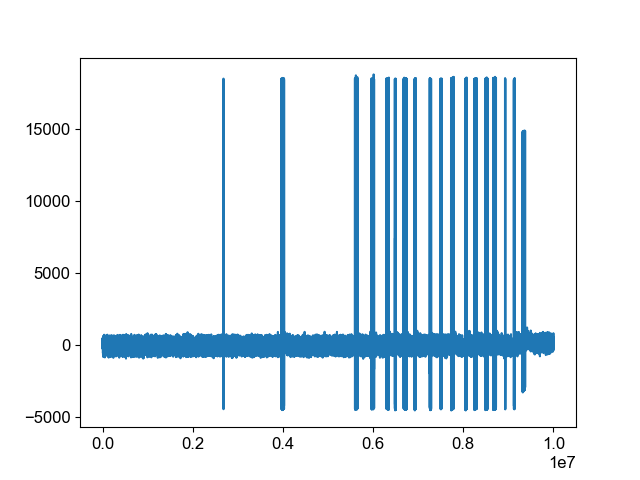

In [94]:
plt.figure()
plt.plot(raw_vis[0:10000000])

In [31]:
x[np.where(np.diff(x) > 0.005 * 30000)[0]]

array([        0,   2682658,   3967526, ..., 200456442, 200466441,
       200468944])

In [32]:
(np.diff(x) > 0.04 * 30000).sum()

4690

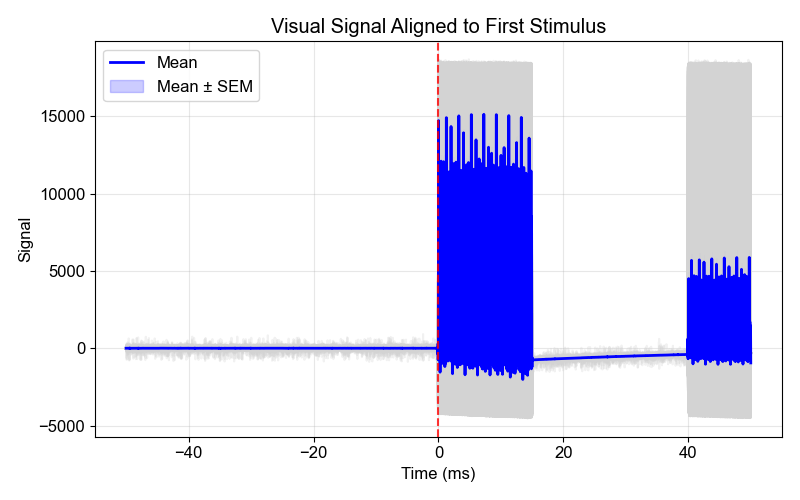

In [33]:
# ...existing code...
# Option 2: Overlay all trials on one axis with mean trace (fixed-length windows)
window_ms = 50
window_sec = window_ms / 1000

dt = np.mean(np.diff(t))  # sampling interval (s)
n_samples = int(np.round(2 * window_sec / dt)) + 1  # +/- window, symmetric

all_traces = []
time_axis = None

for stim_time in first_vis_ts:
    # find center index
    center_idx = int(np.searchsorted(t, stim_time))

    start_idx = center_idx - n_samples // 2
    end_idx = start_idx + n_samples

    # skip if window would go out of bounds
    if start_idx < 0 or end_idx > len(t):
        continue

    time_window = t[start_idx:end_idx] - stim_time
    signal_window = raw_vis[start_idx:end_idx]

    if time_axis is None:
        time_axis = time_window * 1000  # ms

    all_traces.append(signal_window)

all_traces = np.vstack(all_traces)  # (n_trials, n_samples)
mean_trace = all_traces.mean(axis=0)
sem_trace = all_traces.std(axis=0) / np.sqrt(all_traces.shape[0])

plt.figure(figsize=(8, 5))
for trial_trace in all_traces:
    plt.plot(time_axis, trial_trace, color="lightgray", alpha=0.3)

plt.plot(time_axis, mean_trace, color="b", linewidth=2, label="Mean")
plt.fill_between(
    time_axis,
    mean_trace - sem_trace,
    mean_trace + sem_trace,
    color="b",
    alpha=0.2,
    label="Mean ± SEM",
)
plt.axvline(0, color="r", linestyle="--", alpha=0.8)
plt.xlabel("Time (ms)")
plt.ylabel("Signal")
plt.title("Visual Signal Aligned to First Stimulus")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# ...existing code...